# Continuum, Tight-Binding, and Quantum Transport in 1D

This repository studies a one-dimensional free particle and its lattice
realization using tight-binding models. It covers:

1. Continuum–tight-binding scaling
2. The emergence of cosine dispersion from a free particle
3. Quantum transport and conductance using Kwant

---

## 1. Continuum Hamiltonian and Scaling

The continuum Hamiltonian of a free particle is
$$
H = \frac{\hbar^2}{2m} k_x^2.
$$

To compare with a lattice model, we introduce dimensionless variables:
$$
\tilde{k} = k_x a, \qquad
\tilde{E} = E \frac{2 m a^2}{\hbar^2}.
$$

In these units, the dispersion becomes
$$
\tilde{E} = \tilde{k}^2.
$$

The continuum Hamiltonian is discretized using `kwant.continuum.discretize`.
As the lattice spacing $a$ is reduced, the tight-binding band structure
converges to the continuum parabola over an increasing momentum range.

---

## 2. From Free Particle to Cosine Dispersion

For a free particle with chemical potential $\mu$,
$$
E(k) = \frac{\hbar^2 k^2}{2m} - \mu.
$$

On a one-dimensional lattice with nearest-neighbor hopping $t$ and lattice
constant $a$, the tight-binding dispersion is
$$
E(k) = \varepsilon - \mu - 2t \cos(ka).
$$

In the small-$k$ limit,
$$
\cos(ka) \approx 1 - \frac{(ka)^2}{2},
$$
which gives
$$
E(k) \approx (\varepsilon - \mu - 2t) + t a^2 k^2.
$$

Matching the quadratic terms yields the relation
$$
t = \frac{\hbar^2}{2 m a^2}.
$$

Thus, the cosine band reproduces the free-particle dispersion at low energies,
with the hopping amplitude setting the effective mass.

---

## 3. Tight-Binding Chain and Quantum Transport

A finite tight-binding chain of length $L$ is constructed with onsite energy
$2t - \mu$ and nearest-neighbor hopping $-t$:
$$
H = \sum_n (2t - \mu)\, c_n^\dagger c_n
- t \sum_n \left( c_{n+1}^\dagger c_n + \text{h.c.} \right).
$$

The system is connected to two semi-infinite leads with the same hopping $t$
and chemical potential $\mu_{\text{lead}}$.

---

## 4. Conductance Calculation

The two-terminal conductance is computed using the Landauer formula:
$$
G(E) = \frac{e^2}{h} \, T(E),
$$
where $T(E)$ is the transmission probability obtained from the scattering
matrix.

Energies are expressed in units of
$$
\frac{\hbar^2}{2 m a^2}.
$$

The conductance exhibits plateaus between $0$ and $e^2/h$, corresponding to
the opening and closing of propagating modes in the tight-binding chain.

---

## Dependencies

- Python
- NumPy
- SciPy
- Kwant
- Matplotlib



In [1]:
import matplotlib.pyplot as plt

import numpy as np
import scipy

import kwant
import kwant.continuum

import scienceplots
plt.style.use(['science', 'notebook'])

# Band Structure

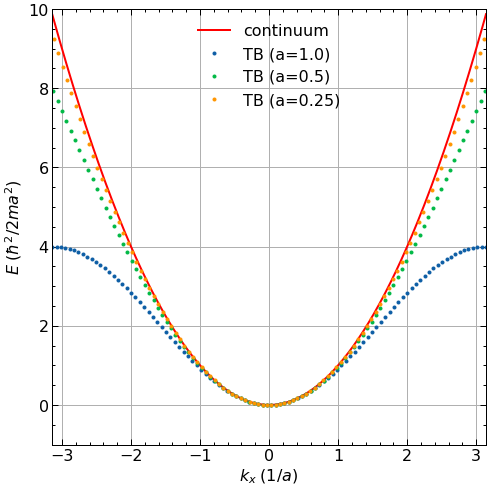

In [2]:
hamiltonian = "k_x**2"

H_k = kwant.continuum.lambdify(hamiltonian)
k_cont = np.linspace(-np.pi, np.pi, 400)
e_cont = [H_k(k_x=k) for k in k_cont]

# ------------------------
# Lattice spacings to test
# ------------------------
a_list = [1.0, 0.5, 0.25]

# ------------------------
# Plot
# ------------------------
plt.figure(figsize=(7,7))

# Continuum (draw once)
plt.plot(k_cont, e_cont, 'r-', lw=2, label='continuum')

# TB for different a
for a in a_list:
    template = kwant.continuum.discretize(hamiltonian, grid=a)

    lead = kwant.Builder(kwant.TranslationalSymmetry([-a]))
    lead.fill(template, shape=lambda site: True, start=[0])
    lead = lead.finalized()

    bands = kwant.physics.Bands(lead)

    momenta = np.linspace(-np.pi/a, np.pi/a, int(100/a))
    energies = [bands(k*a) for k in momenta]

    plt.plot(momenta, energies, '.', lw=2, label=f'TB (a={a})')

# ------------------------
# Formatting
# ------------------------
plt.xlim(-np.pi, np.pi)
plt.ylim(-1, 10)
plt.xlabel(r"$k_x\;(1/a)$")
plt.ylabel(r"$E\;(\hbar^2 / 2 m a^2)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Conductance

In [3]:
def make_system(a,t,L,mu,mu_lead):
    
    lat = kwant.lattice.chain(a, norbs=1)

    # Define the system
    syst = kwant.Builder()
    syst[(lat(i) for i in range(L))] = 2 * t - mu
    #for x in range(L):
    #    syst[lat(x)] = 2 * t - mu
    
    syst[kwant.builder.HoppingKind((1, ), lat)] = -t
    
    # Define the leads
    left_lead = kwant.Builder(kwant.TranslationalSymmetry((-a, )))
    left_lead[(lat(0))] = 2 * t - mu_lead
    left_lead[kwant.builder.HoppingKind((-1, ), lat)] = -t
    
    syst.attach_lead(left_lead)
    syst.attach_lead(left_lead.reversed())

    return syst

In [4]:
def plot_conductance(syst, energies):
    # Compute conductance
    data = []
    for energy in energies:
        smatrix = kwant.smatrix(syst, energy)
        data.append(smatrix.transmission(1, 0))

    plt.figure(figsize=(7,7))
    plt.plot(energies, data, '.')
    plt.xlabel(r"$E\;(\hbar^2 / 2 m a^2)$")
    plt.ylabel("G [e^2/h]")
    plt.ylim(-0.1,1.2)
    plt.show()

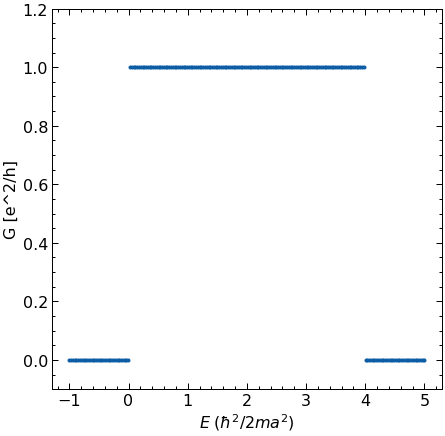

In [5]:
a=1
t=1.0
L=50
mu=0
mu_lead=0

syst = make_system(a,t,L,mu,mu_lead)
E0 = 2*t - mu
energies = np.linspace(E0 - 3*t, E0 + 3*t, 200)

fsyst = syst.finalized()
plot_conductance(fsyst, energies)